## Modified introduction using forex data

This is the trading rule example shown in [the introduction](https://github.com/robcarver17/pysystemtrade/blob/master/docs/introduction.md) but modified to use Interactive Brokers instead of CSV files as data source.  

IB requires a minimum equity and a monthly subscription to provide historical data on future contracts.  This example was modified to use FX prices instead futures to make it runnable with free unfunded paper trading accounts.  Note that Rob [does not recommend trading FX spot data with IB due to their high fees](https://github.com/robcarver17/pysystemtrade/issues/517#issuecomment-1010770678).

First, import the required packages and initialize ib_insync.  

In [1]:
from sysbrokers.IB.ib_connection import connectionIB
from sysbrokers.IB.ib_Fx_prices_data import ibFxPricesData

from ib_insync import util
util.startLoop() #only required when running inside a notebook

Configuring sim logging


Connecting to Interactive Brokers gateway...

In [2]:
conn = connectionIB(314, account="U16129998")
conn

2025-03-31 19:19:30 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults


IB broker connection{'ipaddress': '127.0.0.1', 'port': 4002, 'client': 314}

See what fx instruments we have configured.  These are configured in `sysbrokers/IB/ib_config_spot_FX.csv`

In [3]:
from sysdata.data_blob import dataBlob
ibfxpricedata = ibFxPricesData(conn, dataBlob())
ibfxpricedata.get_list_of_fxcodes()

['AUDUSD',
 'CADUSD',
 'CHFUSD',
 'EURUSD',
 'GBPUSD',
 'HKDUSD',
 'JPYUSD',
 'KRWUSD',
 'CNHUSD',
 'SGDUSD',
 'MXPUSD',
 'SEKUSD']

Now we select one instrument (`EURUSD`) and try to fetch historical data for it.

In [4]:
ibfxpricedata.get_fx_prices('EURUSD')
ibfxpricedata.get_fx_prices('HKDUSD')

2025-03-31 19:19:36 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Updating log attributes
2025-03-31 19:19:40 DEBUG ibFxPricesData Log attributes reset
2025-03-31 19:19:40 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Downloaded 776 prices
2025-03-31 19:19:40 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Updating log attributes
2025-03-31 19:19:41 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Pausing 0.475691 seconds to avoid pacing violation
2025-03-31 19:19:42 DEBUG ibFxPricesData Log attributes reset
2025-03-31 19:19:42 DEBUG ibFxPricesData {'currency_code': 'HKDUSD'} Downloaded 776 prices


2025-03-31 19:19:39 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Reqid -1: 2106 \u5386\u53f2\u5e02\u573a\u6570\u636e\u519c\u573a\u8fde\u63a5\u6b63\u5e38:cashhmds for None


index
2022-04-04 23:00:00    0.127637
2022-04-05 23:00:00    0.127633
2022-04-06 23:00:00    0.127581
2022-04-07 23:00:00    0.127586
2022-04-08 23:00:00    0.127561
                         ...   
2025-03-25 23:00:00    0.128622
2025-03-26 23:00:00    0.128598
2025-03-27 23:00:00    0.128608
2025-03-28 23:00:00    0.128560
2025-03-31 23:00:00    0.128556
Name: FINAL, Length: 776, dtype: float64

Data can also be indexed as a python dict:

In [5]:
ibfxpricedata['HKDUSD']

2025-03-31 19:19:42 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Updating log attributes
2025-03-31 19:19:42 DEBUG ibFxPricesData {'currency_code': 'USDHKD'} Pausing 0.449049 seconds to avoid pacing violation
2025-03-31 19:19:43 DEBUG ibFxPricesData Log attributes reset
2025-03-31 19:19:43 DEBUG ibFxPricesData {'currency_code': 'HKDUSD'} Downloaded 776 prices


index
2022-04-04 23:00:00    0.127637
2022-04-05 23:00:00    0.127633
2022-04-06 23:00:00    0.127581
2022-04-07 23:00:00    0.127586
2022-04-08 23:00:00    0.127561
                         ...   
2025-03-25 23:00:00    0.128622
2025-03-26 23:00:00    0.128598
2025-03-27 23:00:00    0.128608
2025-03-28 23:00:00    0.128560
2025-03-31 23:00:00    0.128556
Name: FINAL, Length: 776, dtype: float64

Create the trading rule

In [6]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

Run a forecast with the previous rule

In [7]:
price=ibfxpricedata['EURUSD']
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

2025-03-31 19:19:43 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Updating log attributes
2025-03-31 19:19:43 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Pausing 0.450853 seconds to avoid pacing violation
2025-03-31 19:19:44 DEBUG ibFxPricesData Log attributes reset
2025-03-31 19:19:44 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Downloaded 776 prices


index
2025-03-25 23:00:00    1.133745
2025-03-26 23:00:00    1.179569
2025-03-27 23:00:00    1.262641
2025-03-28 23:00:00    1.382746
2025-03-31 23:00:00    1.491650
Name: FINAL, dtype: float64

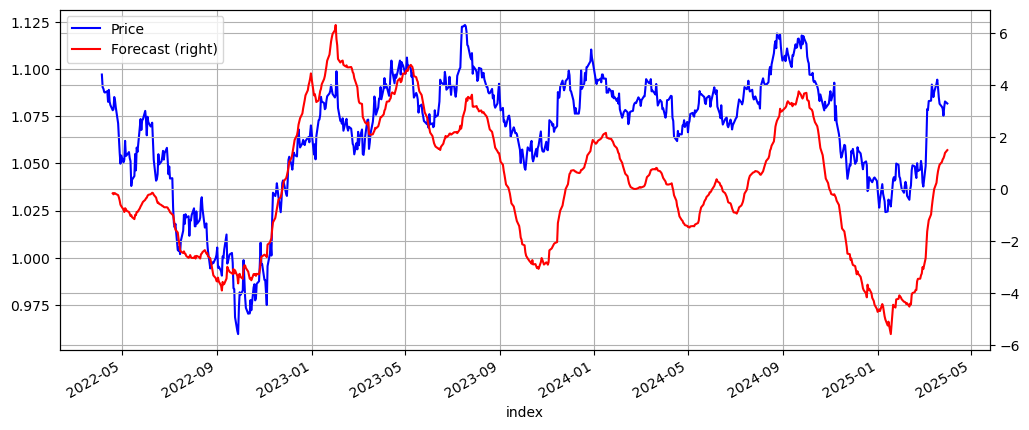

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

ax1 = price.plot(color='blue', grid=True, label='Price')
ax2 = ewmac.plot(color='red', grid=True, secondary_y=True, label='Forecast')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()


plt.legend(h1+h2, l1+l2, loc=2)
plt.show()

The original introduction jumps directly to "Did we make any money?".  
I would like to see here the orders that were triggered by this forecast, but instead we jump directly into P&L.  Still, these are the P&L numbers for this forecast and data:

In [9]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price = price)
account.percent.stats()

[[('min', '-1.682'),
  ('max', '1.653'),
  ('median', '-0.00106'),
  ('mean', '-0.01188'),
  ('std', '0.2683'),
  ('skew', '-0.3453'),
  ('ann_mean', '-3.042'),
  ('ann_std', '4.293'),
  ('sharpe', '-0.7086'),
  ('sortino', '-0.8539'),
  ('avg_drawdown', '-5.615'),
  ('time_in_drawdown', '0.9552'),
  ('calmar', '-0.2334'),
  ('avg_return_to_drawdown', '-0.5417'),
  ('avg_loss', '-0.1764'),
  ('avg_gain', '0.1646'),
  ('gaintolossratio', '0.9332'),
  ('profitfactor', '0.8672'),
  ('hitrate', '0.4817'),
  ('t_stat', '-1.238'),
  ('p_value', '0.2162')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

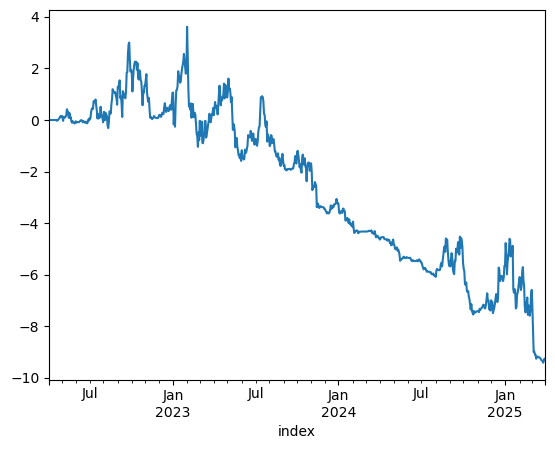

In [10]:
account.curve().plot()
plt.show()

In [11]:
conn.close_connection()

2025-03-31 19:19:45 DEBUG connectionIB {'type': 'connectionIB', 'broker': 'IB', 'clientid': 314} Terminating {'ipaddress': '127.0.0.1', 'port': 4002, 'client': 314}
